In [2]:
from google import genai
from google.genai import types
import pathlib
import httpx

client = genai.Client()

# Retrieve and encode the PDF byte
file_path = pathlib.Path("data/현대차.pdf")


# Upload the PDF using the File API
sample_file = client.files.upload(
    file=file_path,
)

prompt = """pdf파일에서 텍스트 내용을 추출해줘. pdf에는 다양한 텍스트와 테이블, 차트가 포함되어 있어.
            텍스트와 테이블만 추출해줘.
        """

response = client.models.generate_content(
    model="gemini-2.5-pro", contents=[sample_file, prompt]
)
print(response.text)

다음은 요청하신 PDF 파일의 텍스트 및 표 내용입니다.

### **Page 1**

**Company Report 2025.09.02**

**현대차(005380)**

**모든 것을 걸러내도 차고 넘치는 상승여력**

**체질 개선이 아니라 다시 태어난 수준**
원화 약세, 차량용 반도체 부족 등으로 FY22-24 호실적을 기록. 이러한 비유기적 요인으로 인한 실적 피크아웃 우려는 상존했으나, 동사의 본질적인 제품 믹스 개선에 주목할 필요 있음. 2017년 전체 판매량 중 세단 비중 63%, SUV 29%에서 1H25 SUV 55%, 세단 32%로 전체 판매량 중 25%가량이 세단에서 SUV로 개선. 제네시스 판매비중 또한 1.9%에서 5.6%까지 상승 (세단 비중 100%에서 SUV 비중 66%까지 상승).

**최악의 여건에서 최고의 실적을 뽑아내는 금융 부문**
미국내 고금리의 연속에 따른 자동차금융 연체율 역사상 최고점을 기록중. 그럼에도 불구하고 금융부문은 상반기 1.2조원의 영업이익 달성하며 전사 영업이익의 17% 기여. 그 중에서도 현대캐피탈아메리카 (HCA)는 상반기 영업이익 7,400억원 기록 추정. 일반적으로 5년 이상으로 계약하는 자동차금융 특성상 자동차 사업부문 대비 향후 안정적인 이익을 기록할 수 있다는 점에서 전사 이익을 지지할 수 있는 효자사업부문이라 판단. 향후 조달금리 인하시 이익개선 폭이 확대될 것이며, HCA의 높은 오토론 프라임 비중 (90%)으로 연체 리스크 또한 매우 제한적이라 판단.

**투자의견 BUY, 목표주가 300,000원으로 커버리지 개시, Top pick**
SOTP 밸류에이션 기반 (FY25-26F 평균, 금융부문 Target P/E 8배, 이외 5.5배)한 목표주가 300,000원으로 커버리지 개시. 가장 보수적인 자동차부문 P/E multiple 적용 이후에도 막대한 상승여력이 확보되는 것은, 현재 주가가 1) 관세 영향에 대한 우려가 과도하게 반영되었으며, 2) 업종 내 중장기 전동화 관련 리레이

In [3]:
response.usage_metadata

GenerateContentResponseUsageMetadata(
  candidates_token_count=15029,
  prompt_token_count=4169,
  prompt_tokens_details=[
    ModalityTokenCount(
      modality=<MediaModality.TEXT: 'TEXT'>,
      token_count=41
    ),
    ModalityTokenCount(
      modality=<MediaModality.DOCUMENT: 'DOCUMENT'>,
      token_count=4128
    ),
  ],
  thoughts_token_count=2394,
  total_token_count=21592
)

### **Page 1**

**Company Report 2025.09.02**

**현대차(005380)**

**모든 것을 걸러내도 차고 넘치는 상승여력**

**체질 개선이 아니라 다시 태어난 수준**

원화 약세, 차량용 반도체 부족 등으로 FY22-24 호실적을 기록. 이러한 비유기적 요인으로 인한 실적 피크아웃 우려는 상존했으나, 동사의 본질적인 제품 믹스 개선에 주목할 필요 있음. 2017년 전체 판매량 중 세단 비중 63%, SUV 29%에서 1H25 SUV 55%, 세단 32%로 전체 판매량 중 25%가량이 세단에서 SUV로 개선. 제네시스 판매비중 또한 1.9%에서 5.6%까지 상승 (세단 비중 100%에서 SUV 비중 66%까지 상승).

**최악의 여건에서 최고의 실적을 뽑아내는 금융 부문**

미국내 고금리의 연속에 따른 자동차금융 연체율 역사상 최고점을 기록중. 그럼에도 불구하고 금융부문은 상반기 1.2조원의 영업이익 달성하며 전사 영업이익의 17% 기여. 그 중에서도 현대캐피탈아메리카 (HCA)는 상반기 영업이익 7,400억원 기록 추정. 일반적으로 5년 이상으로 계약하는 자동차금융 특성상 자동차 사업부문 대비 향후 안정적인 이익을 기록할 수 있다는 점에서 전사 이익을 지지할 수 있는 효자사업부문이라 판단. 향후 조달금리 인하시 이익개선 폭이 확대될 것이며, HCA의 높은 오토론 프라임 비중 (90%)으로 연체 리스크 또한 매우 제한적이라 판단.

**투자의견 BUY, 목표주가 300,000원으로 커버리지 개시, Top pick**

SOTP 밸류에이션 기반 (FY25-26F 평균, 금융부문 Target P/E 8배, 이외 5.5배)한 목표주가 300,000원으로 커버리지 개시. 가장 보수적인 자동차부문 P/E multiple 적용 이후에도 막대한 상승여력이 확보되는 것은, 현재 주가가 1) 관세 영향에 대한 우려가 과도하게 반영되었으며, 2) 업종 내 중장기 전동화 관련 리레이팅에 대한 공감이 어렵기 때문이라 판단. 9월 예정된 CEO Investor day, GM과의 협업 범위 구체화, 우려 대비 낮은 관세 관련 비용 등이 확인되는 경우 동사의 주가 상승 트리거가 될 것이라 예상. 자동차 사업뿐만 아니라 금융부문 보유로 인한 향후 실적개선 가능성으로 인해 업종 내 Top pick 선정.

---

**김용민 조선/자동차**
yongmin.kim@yuantakorea.com

**BUY (I)**

| 항목 | 값 |
| --- | --- |
| **목표주가** | **300,000원 (I)** |
| **직전 목표주가** | **N.A.** |
| **현재주가 (9/1)** | **220,500원** |
| **상승여력** | **36%** |

| 항목 | 값 |
| --- | --- |
| 시가총액 | 451,491억원 |
| 총발행주식수 | 265,390,108주 |
| 60일 평균 거래대금 | 1,623억원 |
| 60일 평균 거래량 | 765,202주 |
| 52주 고/저 | 259,000원 / 177,500원 |
| 외인지분율 | 36.36% |
| 배당수익률 | 5.66% |
| 주요주주 | 현대모비스 외 11 인 |

| 주가수익률 (%) | 1개월 | 3개월 | 12개월 |
| --- | --- | --- | --- |
| 절대 | 5.0 | 19.0 | (13.7) |
| 상대 | 4.2 | 2.1 | (26.6) |
| 절대(달러환산) | 5.6 | 17.8 | (17.3) |

---

**Quarterly earning Forecasts** (십억원, %)

| | 3Q25E | 전년동기대비 | 전분기대비 | 컨센서스 | 컨센서스대비 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **매출액** | 43,453 | 1.2 | -10.0 | 44,601 | -2.6 |
| **영업이익** | 2,154 | -39.9 | -40.2 | 2,763 | -22.1 |
| **세전계속사업이익** | 2,809 | -35.7 | -36.0 | 3,541 | -20.7 |
| **지배순이익** | 1,647 | -45.9 | -45.1 | 2,478 | -33.6 |
| **영업이익률 (%)** | 5.0 | -3.3%pt | -2.5%pt | 6.2 | -1.2%pt |
| **지배순이익률 (%)** | 3.8 | -3.3%pt | -2.4%pt | 5.6 | -1.8%pt |
자료: 유안타증권

**Forecasts and valuations (K-IFRS 연결)** (십억원, 원, %, 배)

| 결산 (12월) | 2023A | 2024A | 2025F | 2026F |
| :--- | :--- | :--- | :--- | :--- |
| **매출액** | 162,664 | 175,231 | 185,091 | 194,978 |
| **영업이익** | 15,127 | 14,240 | 12,254 | 14,226 |
| **지배순이익** | 11,962 | 12,527 | 10,481 | 11,968 |
| **PER** | 3.5 | 4.2 | 4.7 | 4.0 |
| **PBR** | 0.5 | 0.6 | 0.5 | 0.4 |
| **EV/EBITDA** | 7.6 | 10.7 | 11.4 | 9.9 |
| **ROE** | 13.7 | 12.4 | 9.1 | 9.4 |
자료: 유안타증권

---
### **Page 2**

**현대차(005380)**

**믹스에 대한 이야기**

**폭력적인 믹스개선**

현대차는 지난 수 년간 글로벌 시장 트렌드를 상회하는 믹스 개선세를 이뤄냈다. 동사는 2017년 기준 세단 판매비중 63%를 기록하는 세단 위주의 완성차 업체였다. SUV 및 픽업, MPV, 제네시스 판매를 모두 합쳐도 37%에 불과했기에, 수익성이 낮은 세단 특성상 영업이익률의 상한선이 존재했다. 그러나 1H25 기준 세단의 판매비중은 32% (-31%p)로 낮아졌으며 SUV를 포함한 이외 차종의 비중은 68%로 상승 (+31%p), 글로벌 시장의 세단 판매비중 감소폭인 48%에서 34% (-14%p) 수준을 매우 상회하는 개선세를 기록하였다.

또한, 동사의 프리미엄 브랜드 제네시스 또한 비약적인 성장을 경험했다. 2015년 출범한 제네시스는 초기 세단만을 출시하였으나, 향후 SUV모델인 GV시리즈를 출시하며 SUV 판매비중을 단기간에 끌어올렸다. 향후 GV80 모델을 통해 최초 출시할 하이브리드 (HEV)와 주행거리 연장형 전기차 (EREV) 출시를 통해 지속적인 판매량 증가세와 이에 따른 SUV 판매 비중 상승세를 예상한다.

---
### **Page 3**

**Company Report**

이러한 결과는 단순한 판매 호조가 아니라 외형과 이익의 성장에도 큰 기여를 했다. 2Q19 대비 2Q25 동사는 믹스개선으로 인한 외형 성장 9.5조원을 기록했으며 (자동차부문 전체 매출 79% 성장), 영업이익 측면에서도 1.4조원의 기여도를 보였다 (자동차부문 전체 영업이익 131% 성장).

해당 차트를 통해 확인할 수 있는 추가적인 사실은, 동사의 지난 수 년간의 영업이익 개선세가 매우 유기적이라는 점이다. COVID-19 이후 원화 약세와 차량용 반도체 부족으로 인한 자동차 품귀화 현상 등으로 역대 최고의 실적을 기록한 동사였지만, 이러한 부분들은 비유기적 기타요인으로 대부분 상쇄해도 이익체력이 개선된 점을 확인할 수 있다 (2Q25 영업이익 기준 환율 누적 +2.1조, 기타부문 누적 -1.6조로 5천억원가량의 이익인 반면, 물량 증가와 믹스개선으로 1.9조 이익 기여).

---
### **Page 4**

**현대차(005380)**

**금융부문에 대한 이야기**

**대충 짚고 넘어가기엔 너무나 큰 사업**

동사와 기아의 가장 큰 사업부문별 차이점은 금융사업의 존재 유무이다. 동사는 현대캐피탈, 현대카드, 현대캐피탈아메리카 (HCA)를 보유하고 있는데, 현대카드의 신용카드업을 제외시 자동차 할부금융사업과 리스금융사업이 주를 이루고 있다.

이러한 여신전문 업무를 영위하는 금융부문의 이익기여를 무시할 수 없다. 특히, 1H25 기준 금융부문의 영업이익은 1.2조원을 기록하며 자동차부문 (5.1조)의 24%까지 상승했다. 그 중에서도, 당사 추정 HCA의 영업이익은 1H25 급격한 상승세를 기록하였다. 추정 방법에는 금융부문 전체 영업이익에서 현대카드와 현대캐피탈의 연결영업이익을 제외한 나머지를 HCA의 영업이익이라 가정하였다. 실제로 HCA는 상반기 세전이익 (US GAAP기준) 4.66억불을 기록했는데, 이는 2024년 전체 세전이익의 77%, 2023년 기준으로는 한 해 세전이익의 108% 수준이었다.

**HCA: 최악의 상황에서 최고점을 뚫고 있다면**

HCA의 이익 개선세는 현재 시장 환경이 너무나도 비우호적인 가운데 일어난 것이기에 특별하다. 미국내 고금리의 연속으로 인해 동사의 조달금리는 역사적 고점 수준이며, 이에 따른 전체 시장의 자동차금융 (Auto-loan) 연체율은 역사상 최고점을 기록중이다. 또한, 리스금융 사업으로 인해 충당금 설정 규모에 영향을 줄 수 있는 중고차 가격 또한 최근 변동성을 보이지 않아 특별한 일회성 이익이 발생할 만한 상황이 아니다.

---
### **Page 5**

**Company Report**

말하자면 최악의 영업 환경에 놓여있는 미국 자동차금융 시장에서 HCA는 이익 규모를 늘려왔다. 이에 대해 당사는 1) 조달금리 상승시기 (22-23년) 이후 이를 고객에게 완전히 전가하는 사이클이 도래했으며, 2) Prime등급 신용도를 보유한 고객 비중이 90%에 육박하여 연체율이 매우 낮기 때문에 가능했던 결과라고 판단한다. 일반적으로 자동차금융 사업은 조달금리 상승시 할부금융 금리 또한 상승하나, 주로 5년 이상으로 계약하는 자동차금융 특성상 기존 할부금융에 적용되는 금리를 올리는 데에 시간이 필요했고, 현재는 기존 저금리(저마진) 상품의 매출인식 비중의 의미있게 줄어들고 있다고 판단한다.

---
### **Page 6**

**현대차(005380)**

**결론: 금융부문은 앞으로 안정적으로 더 나아질 것**

높은 금리와 연체율 환경 내에서, 마진 스프레드가 제한적이면서도 보수적인 충당금 설정을 해야 했던 HCA는 그럼에도 불구하고 호실적을 기록중이다. 그렇다면 1) 조달금리가 하락하고, 2) 이에 따라 시장 연체율도 하락한다면 HCA의 실적은 향후에도 더욱 개선될 수 있을 것이다. 또한, 이러한 시장 상황의 변동 없이도 지속적인 영업수익의 증가를 통해 이익 폭을 확대할 수 있을 것이라 판단한다. 이는 곧 이익의 안정성 측면에서 최근 관세 영향을 받고 있는 자동차 사업보다 견조할 것을 의미한다.

---
### **Page 7**

**Company Report**

**관세에 대한 이야기**

**아프겠지만, 생각보다는 덜 아플 것**

트럼프 2.0 이후 자동차 및 부품 수출 관세 부과 우려는 업종 내 최대의 리스크였다. 우여곡절 끝에 15%의 관세율이 확정된 지금, 향후 이로 인한 영향을 예상하는 것이 필수적이다. 2Q25 실적발표를 통해 관세 관련 비용이 확인되었으나, 문제는 해당 비용에는 미국 공장에 납품하는 부품사들의 관세 영향에 대한 비용 분담금도 포함되어 (이 또한 분담 비율은 공개되지 않는다) 있고 관세 영향은 전체 분기가 아닌 5,6월에 발생했기 때문이다.

당사는 추정을 통해 국내에서 미국으로 수출되는 완성차 관세와 미국 현지 생산을 위해 수출되는 부품에 대한 관세 충당금을 분류하였다. 주의할 점은, 자동차에 부과되는 관세는 완성차 업체가 직접적 비용으로 인식하나, 당사가 추정한 수출 부품에 대한 관세 부담은 부품 공급사들이 일차적으로 부담하고 추후 완성차 업체에게 보전하는 충당금 성격의 비용이라는 것이다.

일반적으로 관세를 부과하는 기준은 권장소비자가격 (MSRP)이 아니라 본선인도 (FOB) 당시 가격(제조원가+제조사 수출용 마진+수출항까지 내륙운송비+선적비) 기준이기에 완성차에 한정되는 관세 영향을 정확히 추정하기는 사실상 불가능하다. 그럼에도 불구하고 이를 추정하기 위해, 다음과 같은 방법을 채택한다. 1) 2Q25 소매판매 기준 미국생산 물량과 수출물량의 매출 비중을 추정, 2) 완성차 부문 관세대상 금액을 추정한다. 또한 3) 미국 현지생산에 투입되는 수출 부품의 비중을 구하고 4) 해당 부품에 부과되는 관세가 완성차 업체에 얼마나 전가될 수 있는지 추정한다. 여기서 2)와 4)를 통해 각각 완성차 부문 관세와 부품 부문 충당금을 분리할 수 있다.

**정보 1) 2Q25 소매기준 북미에서 생산된 현대차 모델별 판매대수와 MSRP**

| 2Q25 | 소매판매(대) | 가격(천 불) |
| --- | --- | --- |
| Tucson | 35,371 | 31 |
| SantaCruz | 7,573 | 37 |
| SantaFe | 20,076 | 40 |
| SantaFe HEV | 13,601 | 43 |
| GV70 | 6,031 | 59 |
| GV70 EV | 467 | 69 |
| Ioniq5 | 9,711 | 50 |
| Ioniq9 | 1,013 | 68 |
| Tucson (멕시코) | 5,483 | 31 |
| **총합 (가격은 가중평균치)** | **99,326** | **39** |

**정보 2) 판매법인 매출을 통한 전체 대당 매출**

| | 2Q25 |
| :--- | :--- |
| **HMA (미국 판매법인) 매출 (십억 원)** | 13,050 |
| **소매기준 한국생산량 (대)** | 156,253 |
| **소매기준 미국생산량 (대)** | 99,326 |
| **전체 소매대수 (대)** | 255,579 |
| **대당 매출 (백만 원)** | 51 |

---
### **Page 8**

**현대차(005380)**

**완성차 수출을 통해서 발생하는 매출 추정과 실질적으로 발생한 관세 관련 비용을 통한 관세대상 금액 추정**

| | | 비고 |
| :--- | :--- | :--- |
| 2Q25 전체 소매판매 (대) | 255,579 | [A] |
| 2Q25 소매판매중 수출물량 (대) | 156,253 | [B] |
| 비중 | 61.1% | 전체 소매판매량 내 수출물량 비중 |
| 2Q25 소매판매중 현지물량 (대) | 99,326 | [C] |
| 비중 | 38.9% | 전체 소매판매량 내 미국생산 비중 |
| HMA (판매법인) 전체매출 (십억 원) | 13,050 | [D] |
| 미국생산 물량 대당 매출 (천 불) | 37 | [E], 딜러 인센티브 2천 불 매출감소 반영 |
| 미국생산 물량 매출 (백만 불) | 3,678 | [F]=[C]*[E]/10^3 |
| 미국생산 물량 매출 (십억 원) | 5,150 | [G]=[F]*1.4 |
| HMA 매출내 비중 | 39.5% | [H]=[G]/[D] |
| 수출물량 매출 (십억 원) | 7,900 | [I]=[D]-[G] |
| 수출물량 대당 매출 (백만 원) | 51 | [J]=[I]/[B]*10^3 |
| 5,6월 2개월치 관세 비용 (십억 원) | 828 | [K] |
| 분기 환산 (십억 원) | 1,242 | [L]=[K]*1.5 |
| 관세대상 금액 (십억 원) | 4,968 | [M]=[L]*4 (관세 25% 역산) |

앞서 언급한 것처럼, 관세부과의 기준은 최종 매출이 아닌 FOB 당시 가격에 기반하기 때문에, 수출물량의 매출 전체 (7.9조 원)은 2Q25 실적발표에서 추정할 수 있는 관세대상 금액 (5조 원)을 매우 상회한다. 따라서 부품 수출에 따른 관세의 영향에 대한 추정도 병행한다. 가장 먼저, 2Q25 미국내 판매된 모델의 각 국가별 부품 사용비중을 구한 뒤, 판매량에 따라 가중평균치를 구하여 전체적인 부품 사용비중을 추정하였다. 대당 매출액의 경우, 수출 물량 (5,056만 원)과 전체 소매 (5,106만 원), 미국생산 물량 (37,034 불)의 가격 추정치가 거의 일치하여 단순 판매량에 따라 비중을 구하였다.

**미국에서 판매되는 현대차 모델의 미국부품 및 한국부품 사용비중**

| 모델명 | 2Q25 소매판매량 | 미국부품 비중 | 한국부품 비중 | 조립국가 | 모델명 | 2Q25 소매판매량 | 미국부품 비중 | 한국부품 비중 | 조립국가 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Elantra | 34,245 | 0% | 90% | 한국 | G70 | 2,761 | 3% | 85% | 한국 |
| Elantra HEV | 5,137 | 0% | 90% | 한국 | G80 | 893 | 3% | 80% | 한국 |
| Elantra N | 1,896 | 0% | 80% | 한국 | G80 EV | 26 | 2% | 70% | 한국 |
| Ioniq 5 N | 770 | 1% | 65% | 한국 | G90 | 365 | 2% | 80% | 한국 |
| Ioniq 6 | 3,004 | 1% | 90% | 한국 | GV60 | 459 | 1% | 70% | 한국 |
| Kona | 21,820 | 2% | 90% | 한국 | GV70 | 2,464 | 3% | 85% | 한국 |
| Kona EV | 990 | 0% | 45% | 한국 | GV80 | 6,387 | 3% | 85% | 한국 |
| Nexo | 2 | 1% | 80% | 한국 | Ioniq 5 | 5,000 | 63% | 29% | 미국 |
| Palisade | 30,962 | 2% | 90% | 한국 | Ioniq 5 | 4,711 | 29% | 29% | 미국 |
| Sonata | 12,497 | 0% | 90% | 한국 | Santa Cruz | 7,573 | 60% | 27% | 미국 |
| Sonata HEV | 4,692 | 0% | 90% | 한국 | Santa Fe | 20,076 | 47% | 36% | 미국 |
| Tucson | 68 | 1% | 90% | 한국 | Santa Fe HEV | 13,601 | 39% | 46% | 미국 |
| Tucson HEV | 15,991 | 1% | 85% | 한국 | Tucson | 35,371 | 55% | 30% | 미국 |
| Tucson PHEV | 1,424 | 0% | 90% | 한국 | GV70 | 6,031 | 25% | 70% | 미국 |
| Venue | 9,400 | 1% | 90% | 한국 | GV70 EV | 467 | 17% | 80% | 미국 |
| **전체** | **254,566** | **19% (미국생산 48%)** | **69% (미국생산 36%)** | Tucson | 5,483 | 15% | 55% | 멕시코 |

---
### **Page 9**

**Company Report**

미국내 생산되는 자동차 부품 중 48%는 미국산이다. 이에 따라 관세에 노출된 수출부품의 비중은 50% 수준이라는 점을 알 수 있다. 그러나 1) 2Q25 실적발표 당시 부품 조달의 현지화 노력이 진행중이라는 점을 언급한 것(NHTSA 자료는 1월 공개됨)과 2) 기아의 현지조달 부품 비중(59%)을 고려해 당사는 2Q25 현대차 관세 관련 비용에는 미국 생산 자동차의 약 60%의 부품에 대한 25% 관세가 반영되어 있었다고 추정한다.

일반적인 자동차 GPM 20%를 제외한 전체 매출원가 (80%) 내에서 원재료의 비중이 약 75%라는 점을 감안하여, 매출액 대비 부품 비용의 비중은 50-60% 수준이라 추정한다. 결국 2Q25 분기 전체로 환산된 관세 비용 1.24조원 중 1,700-2,830억 원 정도는 부품사를 위해 설정해 둔 것이라는 결과가 도출된다. 동사가 부품사의 관세 비용에서 높은 비중을 부담해 줄 것이라(60~100%) 가정한 이유는 동사가 부품 관련 비용인하를 충분히 진행한 상황이기에 관세와 같은 비용은 상당부분 이상 보전해줄 것이라 판단하기 때문이다.

그렇다면 다시 원점으로 돌아와서, 자동차 자체에 부과되는 관세로 인한 비용 9.6천억-1.07조원은 당시 25% 관세율 역산을 통해 2Q25 FOB 당시 관세부과 대상 금액이 3.8조-4.3조원 수준이었다는 것을 유추할 수 있다. 앞선 추정에서 수출물량 매출이 7.9조원이었다는 점을 감안한다면, 실제로 관세 부과시의 기준인 FOB 가격은 실제 매출의 49-54% 수준에 해당하여 예상보다 관세 영향이 제한적일 것이라는 결론에 도달할 수 있다. 이러한 동사 추정치를 완전히 적용시, 판매량의 변동이 없다는 전제 하에 3-4분기 관세율 할인에 따른 관세 관련 비용은 2분기 (분기환산 1.2조) 대비 4분기 7,450억까지 내려갈 수 있다.

---
**미국에서 생산된 자동차의 부품내 수출부품 비중과, 매출대비 전체 부품비용 비중에 따른 현대차의 2Q25 부품 관련 충당금 추정 (단위: 십억 원)**

**부품사 관세비용 60% 부담시**
| 수출 부품 비중 | 매출대비 전체 부품비용 비중 |
| :--- | :--- | :--- | :--- |
| | 50% | 55% | 60% |
| 35% | 135 | 149 | 162 |
| 40% | 154 | 170 | 185 |
| 45% | 174 | 191 | 209 |

**부품사 관세비용 70% 부담시**
| 수출 부품 비중 | 매출대비 전체 부품비용 비중 |
| :--- | :--- | :--- | :--- |
| | 50% | 55% | 60% |
| 35% | 158 | 173 | 189 |
| 40% | 180 | 198 | 216 |
| 45% | 203 | 223 | 243 |

**부품사 관세비용 80% 부담시**
| 수출 부품 비중 | 매출대비 전체 부품비용 비중 |
| :--- | :--- | :--- | :--- |
| | 50% | 55% | 60% |
| 35% | 180 | 198 | 216 |
| 40% | 206 | 227 | 247 |
| 45% | 232 | 255 | 278 |

**부품사 관세비용 100% 부담시**
| 수출 부품 비중 | 매출대비 전체 부품비용 비중 |
| :--- | :--- | :--- | :--- |
| | 50% | 55% | 60% |
| 35% | 225 | 248 | 270 |
| 40% | 257 | 283 | 309 |
| 45% | 290 | 319 | 348 |

---
**당사 추정 2Q25 관세 비용 Breakdown**

| | |
| :--- | :--- |
| 2Q25 분기환산 관세 비용 (십억 원) | 1,242 |
| 2Q25 소매 수출 물량 (대) | 156,253 |
| 수출 완성차 대상 관세 | 9,590억-1.07조 |
| 수출 차량당 관세 부과 (25%) | 614-686만원 |
| 2Q25 소매 현지 물량 (대) | 99,326 |
| 현재 생산 대상 관세 | 1,700억-2,830억 |
| 현지생산 1대당 부품 관세 부담 (25%) | 171-285만 원 |

**당사 예상 3Q25-4Q25 관세 비용 Breakdown**

| 3Q25 - 25% | |
| :--- | :--- |
| 현지생산 1대당 부품 관세 부담 | 171-285만 원 |
| 수출 차량당 관세 부과 | 614-686만 원 |
| **4Q25 - 15% 관세 완전 반영** | |
| 현지생산 1대당 부품 관세 부담 (15%) | 102-170만 원 |
| 수출 차량당 관세 부과 (15%) | 368-412만 원 |

---
### **Page 10**

**현대차(005380)**

**HMGMA에 관한 이야기**

**관세 충격이 HMGMA 단기 생산 전략에 변화를 주지는 않을 것**

미국발 관세에 대한 대응 방안으로 고려되는 옵션 중 하나는 작년 가동을 시작한 조지아공장 (HMGMA)을 통해 현지 생산 비중을 확대하는 것이다. 그러나, 당사는 밸류체인 특성상 이러한 전략 변화가 일어날 가능성이 제한적이라 판단한다. 가장 먼저, ICE 혼류생산 가능성은 매우 제한적이다. 애초에 HMGMA는 BEV 전용공장 목적으로 건설되었으며, 기존에 가동중인 앨라배마 공장 (HMMA)에서 ICE를 생산중이다.

다음으로, HEV 생산에 대해서도 회사 입장에서 단기간 내에 대량생산 체제를 확보하기는 힘들 것이라 예상한다. 동사는 올해 초 팰리세이드 LX3 HEV를 출시했는데, 이는 동사의 차세대 하이브리드 시스템인 TMED-2가 최초로 적용된 모델이다. HEV 시스템의 세대교체가 이뤄진 현 시점에서, 향후 미국 시장에 출시할 신규 HEV 모델은 TMED-2를 채용할 확률이 매우 높다. TMED-2 시스템 적용을 위해서는 넘어야 할 산이 두 개가 있는데, 1) 생산에 필요한 하위 공급사들의 미국공장 신설과 2) 해당 모델의 해외 생산을 위한 노조와의 합의이다.

또한, 현지 생산을 통한 관세 절약과 비용 상승의 상쇄를 고려해야 한다. 미국 지역이 높은 영업이익 기여도를 자랑했던 이유는 비교적 생산비용이 저렴한 한국에서 만들어 미국으로 수출하는 마진이 높았기 때문인데, 현지 생산 비중을 확대할 경우 전체적인 이익률에 악영향을 줄 수 있다. 실제로, 미국내 생산되는 자동차의 원자재 매입 비용은 지속적으로 증가 (물론 매출도 증가)하고 있다. 수출 물량에는 선적비, 운반비, 관세 등의 비용이 포함될 수 있어 단순히 차량 매출 대비 원자재 매입을 비교하는 것은 무리가 있으나, 그럼에도 불구하고 미국내 생산비중 확대가 무조건적인 답안은 아니라는 것이다.

---
### **Page 11**

**Company Report**

**협업에 관한 이야기**

**GM과의 차량 공동 개발=앞서 언급한 장벽 제거 요소**

8월 현대차와 GM이 픽업트럭과 전기 밴 등 차량 5종을 공동 개발하기로 발표했다. 양사는 중남미 시장용 차량 4종 (픽업 2종, 승용 1종, SUV 1종)과 북미 시장용 전기 상용 밴 차량을 공동 개발해 나갈 계획이라 밝혔으며, 중남미 시장용 차량은 ICE뿐만 아니라 HEV 시스템 탑재도 가능할 것이라 보도되었다. 당사는 이에 대해 전기 상용 밴 협업보다 HEV 시스템 탑재가 가능한 중남미 시장용 차량 공동개발이 더 의미있다고 판단한다.

**전기 상용 밴 - GM은 개선이 절박, 현대에겐 중장기 비용 절감**

북미 시장용 전기 상용 밴에 대한 공동개발은 GM의 요청에 의한 것이라 판단한다. 북미 전기 상용차 시장은 대표적으로 GM, Ford, Rivian, Mercedes 4사의 주력 상용 전기차가 경쟁하는데, 여기서 GM은 설 자리를 잃어버렸기 때문이다. 현대차의 입장에선 기보유한 상용 전기차인 ST1을 개량하여 GM과의 합작을 통한 중장기적 플랫폼 공유 및 이로 인한 비용 절감이 가능할 것이라 예상한다.

**중남미 차량 4종에 현대의 TMED-2 시스템이 적용되면**

마찬가지로 GM은 HEV 시장에서도 경쟁력이 없다. EV캐즘이 지속되며 HEV 판매량 전망치가 상승하고 있는 국면에서, GM 입장에서는 HEV 또한 현대차의 TMED-2 시스템의 적용을 절실하게 원할 것이라 판단한다. 만약 GM 북미공장에서 TMED-2 기반 HEV 양산이 현실화된다면, 앞서 언급한 하위 공급사들의 미국 진출에 대한 부담이 규모의 경제로 인해 완화될 것이라 판단한다.

---
### **Page 12**

**현대차(005380)**

**미주 전체 HEV 판매량 - 현대차와 기아의 합산 점유율은 도요타와 혼다그룹 다음으로 3위**

| (판매 대수) | 2020 | 2021 | 2022 | 2023 | 2024 | 1H25 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Toyota (그룹)** | 391,620 | 633,107 | 559,298 | 747,401 | 1,129,053 | 633,585 |
| **Honda (그룹)** | 61,405 | 105,080 | 96,907 | 293,875 | 316,703 | 203,273 |
| **현대차** | 13,468 | 58,774 | 63,362 | 89,300 | 132,785 | 77,292 |
| **기아** | 15,323 | 24,408 | 48,551 | 83,749 | 75,608 | 62,805 |
| **Ford (그룹)** | 52,632 | 90,631 | 98,911 | 127,058 | 182,035 | 111,974 |
| **Mazda** | 0 | 2 | 4,811 | 7,312 | 32,621 | 53,201 |
| **Geely Holding Group** | 0 | 0 | 1,408 | 1,356 | 1,700 | 44,169 |

**밸류에이션 및 목표주가**

**최대한 보수적으로 걸러봐도, 너무나도 높은 상승여력**

동사에 대한 SOTP 기반 목표주가를 300,000원으로 제시한다. FY25-26F 평균 자동차사업 및 기타사업의 세후영업이익 (NOPAT)에 Target P/E 5.5배를 적용하며, 이는 Global peer 및 동사의 역사적 P/E band 상에서도 최하단에 위치하며, 이에 대한 근거는 1) 현재 형성된 이익 예상치에 대한 시장의 불확실성 및 2) 전동화 기반 신기술 적용에 있어 글로벌 BEV 선도업체 대비 상대적인 가시성 부족이다.

금융부문에 대해서는 Target P/E 8배를 적용한다. 자동차 사업이나 기타사업 대비 높은 P/E multiple을 적용하는 이유는 1) 자동차 할부금융은 관세 적용으로 인한 영향이 제한적이며, 2) 사업 특성상 이익의 낙폭이 제한적이며 향후 시장 상황 개선에 따라 더욱 이익폭이 증가할 수 있기 때문이다. 주력 사업에 대한 보수적인 밸류에이션을 적용함에도 불구하고 높은 상승여력을 보유했으며, 이익 불확실성의 확대에 따른 주가 하락폭이 과도한 시점이라 판단하여 자동차/부품 업종 내에서 Top pick으로 선정한다.

**현대차: Valuation 및 목표주가**

| | FY25F | FY26F |
| :--- | :--- | :--- |
| **자동차 사업 NOPAT** | 6,390 | 7,190 |
| Target P/E | | 5.5 |
| **금융부문 NOPAT** | 2,021 | 2,363 |
| Target P/E | | 8.0 |
| **기타부문 NOPAT** | 1,029 | 1,109 |
| Target P/E | | 5.5 |
| **자동차부문 적정가치 (십억 원)** | 37,346 |
| **금융부문 적정가치 (십억 원)** | 17,534 |
| **기타부문 적정가치 (십억 원)** | 5,880 |
| **적정 시가총액 (십억 원)** | 60,760 |
| **보통주 주식발행수 (천 주)** | 204,758 |
| **목표주가** | 297,000 |

---
### **Page 13**

**Company Report**

**글로벌 완성차 업체 및 미국 자동차금융 업체 peer valuation**

| | Ticker | 단위 | 주가 | 시총 (백만 불) | 절대수익률 (%) | | | | 지수 | 지수대비 수익률(%) | | | | P/E (x) | | P/BV (x) | |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| | | | | | 1M | 3M | 6M | 12M | | 1M | 3M | 6M | 12M | 25F | 26F | 25F | 26F |
| **미국** | | | | | | | | | | | | | | | | | |
| Ford | F US | USD | 12 | 46,843 | 7.7 | 16.7 | 26.7 | 14.0 | SPX Index | 6.3 | 7.4 | 18.2 | (1.5) | 10.6 | 8.7 | 1.0 | 1.0 |
| GM | GM US | USD | 59 | 55,782 | 12.4 | 21.0 | 19.9 | 19.7 | SPX Index | 11.0 | 11.7 | 11.4 | 4.2 | 6.3 | 6.1 | 0.8 | 0.8 |
| **유럽** | | | | | | | | | | | | | | | | | |
| Daimler | MBG GY | EUR | 54 | 60,743 | 1.1 | 1.9 | (2.2) | (6.3) | DAX Index | 1.8 | 1.5 | (8.8) | (33.4) | 9.1 | 7.8 | 0.6 | 0.5 |
| BMW | BMW GY | EUR | 91 | 67,266 | 5.0 | 15.3 | 13.8 | 13.9 | DAX Index | 5.8 | 14.9 | 7.3 | (13.2) | 8.4 | 7.6 | 0.6 | 0.6 |
| VW | VOW GY | EUR | 103 | 59,783 | 5.1 | 5.2 | 2.1 | 5.8 | DAX Index | 5.9 | 4.8 | (4.5) | (21.2) | 5.6 | 4.3 | 0.3 | 0.3 |
| **일본** | | | | | | | | | | | | | | | | | |
| Honda | 7267 JP | JPY | 1,669 | 59,944 | 5.8 | 13.7 | 22.7 | 9.9 | TPX Index | 1.9 | 4.4 | 8.5 | (3.0) | 8.0 | 11.6 | 0.6 | 0.6 |
| Nissan | 7201 JP | JPY | 336 | 8,476 | 1.2 | (9.1) | (22.0) | (21.2) | TPX Index | (2.7) | (18.4) | (36.2) | (34.1) | (6.9) | (4.5) | 0.2 | 0.2 |
| Toyota | 7203 JP | JPY | 2,859 | 307,122 | 4.9 | 3.2 | 8.2 | 7.0 | TPX Index | 1.0 | (6.1) | (6.0) | (5.9) | 8.3 | 11.2 | 1.0 | 1.0 |
| **중국** | | | | | | | | | | | | | | | | | |
| GWM | 2333 HK | HKD | 19 | 28,479 | 49.8 | 62.5 | 53.7 | 76.4 | HSI Index | 45.2 | 52.5 | 42.0 | 34.0 | 12.0 | 10.3 | 1.8 | 1.6 |
| BAIC | 1958 HK | HKD | 2 | 2,108 | (4.2) | 3.5 | (14.2) | 10.8 | HSI Index | (8.7) | (6.5) | (25.9) | (31.6) | 8.9 | 8.3 | 0.3 | 0.3 |
| Geely | 175 HK | HKD | 19 | 24,744 | 8.3 | 10.6 | 11.1 | 120.9 | HSI Index | 3.7 | 0.6 | (0.6) | 78.5 | 12.1 | 10.2 | 1.9 | 1.6 |
| **한국** | | | | | | | | | | | | | | | | | |
| 현대차 | 005380 KS | KRW | 220,500 | 32,418 | 6.2 | 20.4 | 17.1 | (8.1) | KOSPI Index | 5.5 | 3.9 | (7.0) | (25.7) | 4.9 | 4.8 | 0.5 | 0.5 |
| 기아 | 000270 KS | KRW | 106,500 | 30,113 | 5.7 | 19.1 | 22.3 | 7.4 | KOSPI Index | 4.9 | 2.6 | (1.8) | (10.1) | 4.8 | 4.8 | 0.7 | 0.6 |
| **산업 평균** | | | | **60,294** | **8.4** | **14.2** | **12.2** | **19.3** | | **6.3** | **5.6** | **(0.3)** | **(4.8)** | **7.1** | **7.0** | **0.8** | **0.7** |
| **미국 자동차금융 업체** | | | | | | | | | | | | | | | | | |
| Ally Financial | ALLY US | KRW | 41 | 12,636 | 7.4 | 17.3 | 12.6 | (0.0) | SPX Index | 6.0 | 8.0 | 4.1 | (15.6) | 11.4 | 7.6 | 1.0 | 0.9 |
| Credit Acceptance Corp | CACC US | KRW | 515 | 5,784 | (0.2) | 6.6 | 4.5 | 9.0 | SPX Index | (1.6) | (2.7) | (4.0) | (6.6) | 13.1 | 11.2 | 3.3 | 2.4 |
| **산업 평균** | | | | **9,210** | **3.6** | **11.9** | **8.6** | **4.5** | | **2.2** | **2.7** | **0.1** | **(11.1)** | **12.2** | **9.4** | **2.2** | **1.6** |

---
### **Page 14**

**현대차(005380) 추정재무제표(K-IFRS 연결)**

**손익계산서 (단위: 십억원)**
| 결산(12월) | 2023A | 2024A | 2025F | 2026F | 2027F |
| --- | --- | --- | --- | --- | --- |
| 매출액 | 162,664 | 175,231 | 185,091 | 194,978 | 205,856 |
| 매출원가 | 129,179 | 139,482 | 150,133 | 156,278 | 164,782 |
| 매출총이익 | 33,484 | 35,749 | 34,959 | 38,700 | 41,074 |
| 판관비 | 18,357 | 21,510 | 22,704 | 24,474 | 25,889 |
| 영업이익 | 15,127 | 14,240 | 12,254 | 14,226 | 15,185 |
| EBITDA | 20,073 | 18,527 | 17,292 | 19,861 | 21,284 |
| 영업외손익 | 2,492 | 3,542 | 2,704 | 2,855 | 3,373 |
| ... (중략) | | | | | |
| 지배지분순이익 | 11,962 | 12,527 | 10,481 | 11,968 | 13,003 |
| 지배지분포괄이익 | 12,204 | 17,100 | 15,076 | 16,548 | 17,571 |

**재무상태표 (단위: 십억원)**
| 결산(12월) | 2023A | 2024A | 2025F | 2026F | 2027F |
| --- | --- | --- | --- | --- | --- |
| 유동자산 | 58,604 | 64,336 | 67,301 | 71,058 | 73,138 |
| 현금및현금성자산 | 19,167 | 19,015 | 22,042 | 23,699 | 23,409 |
| 비유동자산 | 116,172 | 147,622 | 155,900 | 163,285 | 170,009 |
| 자산총계 | 282,463 | 339,798 | 357,434 | 375,288 | 391,139 |
| 유동부채 | 73,362 | 79,510 | 81,387 | 83,131 | 84,795 |
| 비유동부채 | 107,292 | 140,013 | 143,846 | 145,417 | 143,974 |
| 부채총계 | 180,654 | 219,522 | 225,233 | 228,549 | 228,769 |
| 지배지분 | 92,497 | 109,103 | 120,439 | 134,306 | 149,207 |
| 자본총계 | 101,809 | 120,276 | 132,200 | 146,739 | 162,370 |

**현금흐름표 (단위: 십억원)**
| 결산(12월) | 2023A | 2024A | 2025F | 2026F | 2027F |
| --- | --- | --- | --- | --- | --- |
| 영업활동 현금흐름 | -2,519 | -5,662 | -1,453 | 608 | 1,539 |
| 투자활동 현금흐름 | -8,649 | -14,623 | -11,978 | -13,684 | -13,567 |
| 재무활동 현금흐름 | 9,393 | 19,493 | 15,861 | 13,904 | 10,907 |
| 현금의 증감 | -1,698 | -152 | 3,027 | 1,657 | -290 |
| 기말 현금 | 19,167 | 19,015 | 22,042 | 23,699 | 23,409 |
| FCF | -9,590 | -13,723 | -10,253 | -7,892 | -6,561 |

**Valuation 지표 (단위: 원, 배, %)**
| 결산(12월) | 2023A | 2024A | 2025F | 2026F | 2027F |
| --- | --- | --- | --- | --- | --- |
| EPS | 53,295 | 56,300 | 47,403 | 55,021 | 60,073 |
| BPS | 351,861 | 413,568 | 462,701 | 515,974 | 573,221 |
| DPS | 11,400 | 12,000 | 12,000 | 12,000 | 12,000 |
| PER | 3.5 | 4.2 | 4.7 | 4.0 | 3.7 |
| PBR | 0.5 | 0.6 | 0.5 | 0.4 | 0.4 |
| EV/EBITDA | 7.6 | 10.7 | 11.4 | 9.9 | 9.2 |
| PSR | 0.3 | 0.4 | 0.3 | 0.3 | 0.3 |

**재무비율 (단위: 배, %)**
| 결산(12월) | 2023A | 2024A | 2025F | 2026F | 2027F |
| --- | --- | --- | --- | --- | --- |
| 매출액 증가율(%) | 14.4 | 7.7 | 5.6 | 5.3 | 5.6 |
| 영업이익 증가율(%) | 54.0 | -5.9 | -13.9 | 16.1 | 6.7 |
| 영업이익률(%) | 9.3 | 8.1 | 6.6 | 7.3 | 7.4 |
| ROE | 13.7 | 12.4 | 9.1 | 9.4 | 9.2 |
| 부채비율(%) | 177.4 | 182.5 | 170.4 | 155.8 | 140.9 |
| 순차입금/자기자본(%) | 104.6 | 116.8 | 108.1 | 96.3 | 85.4 |

---
### **Page 15**

**Company Report**

**현대차(005380) 투자등급 및 목표주가 추이**

| 일자 | 투자 의견 | 목표가 (원) | 목표가격 대상시점 | 괴리율 - 평균주가 대비 | 괴리율 - 최고(최저) 주가 대비 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 2025-09-02 | BUY | 300,000 | 1년 | | |
| | 담당자변경 | | | | |
| 2025-02-07 | BUY | 380,000 | 1년 | -46.90 | -41.32 |
| 2024-08-29 | BUY | 380,000 | 1년 | -41.32 | -31.84 |
| 2024-07-04 | BUY | 350,000 | 1년 | -27.11 | -19.14 |
| 2024-04-26 | BUY | 330,000 | 1년 | -19.72 | -9.70 |
| 2023-10-27 | BUY | 290,000 | 1년 | -27.21 | -11.90 |
| 2023-04-26 | BUY | 330,000 | 1년 | -40.64 | -36.36 |

**투자의견 비율(%)**

| 구분 | 투자의견 비율(%) |
| :--- | :--- |
| Strong Buy(매수) | 0 |
| Buy(매수) | 93.6 |
| Hold(중립) | 6.4 |
| Sell(비중축소) | 0 |
| 합계 | 100.0 |

---
### **Page 16**

**현대차(005380)**

**Appendix**

*   이 자료에 게재된 내용들은 본인의 의견을 정확하게 반영하고 있으며 타인의 부당한 압력이나 간섭 없이 작성되었음을 확인함. (작성자 : 김용민)
*   당사는 자료공표일 현재 동 종목 발행주식을 1%이상 보유하고 있지 않습니다.
*   당사는 자료공표일 현재 해당 기업과 관련하여 특별한 이해관계가 없습니다.
*   당사는 동 자료를 전문투자자 및 제 3자에게 사전 제공한 사실이 없습니다.
*   동 자료의 금융투자분석사와 배우자는 자료공표일 현재 대상법인의 주식관련 금융투자상품 및 권리를 보유하고 있지 않습니다.
*   종목 투자등급 (Guide Line): 투자기간 12개월, 절대수익률 기준 투자등급 4단계(Strong Buy, Buy, Hold, Sell)로 구분한다
*   Strong Buy: +30%이상 Buy: 15%이상, Hold: -15% 미만 ~ +15% 미만, Sell: -15%이하로 구분
*   업종 투자등급 Guide Line: 투자기간 12개월, 시가총액 대비 업종 비중 기준의 투자등급 3단계(Overweight, Neutral, Underweight)로 구분
*   2014년 2월21일부터 당사 투자등급이 기존 3단계 + 2단계에서 4단계로 변경

본 자료는 투자자의 투자를 권유할 목적으로 작성된 것이 아니라, 투자자의 투자판단에 참고가 되는 정보제공을 목적으로 작성된 참고 자료입니다. 본 자료는 금융투자분석사가 신뢰할만 하다고 판단되는 자료와 정보에 의거하여 만들어진 것이지만, 당사와 금융투자분석사가 그 정확성이나 완전성을 보장할 수는 없습니다. 따라서, 본 자료를 참고한 투자자의 투자의사결정은 전적으로 투자자 자신의 판단과 책임하에 이루어져야 하며, 당사는 본 자료의 내용에 의거하여 행해진 일체의 투자행위 결과에 대하여 어떠한 책임도 지지 않습니다. 또한, 본 자료는 당사 투자자에게만 제공되는 자료로 당사의 동의 없이 본 자료를 무단으로 복제 전송 인용 배포하는 행위는 법으로 금지되어 있습니다.

### 차트를 이미지로 가져오기 위한 과정

In [7]:
!pip install supervision

In [12]:
#!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
#!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

In [13]:
import requests

urls = [
    "https://media.roboflow.com/notebooks/examples/dog-2.jpeg",
    "https://media.roboflow.com/notebooks/examples/dog-3.jpeg"
]

for url in urls:
    filename = url.split("/")[-1]
    response = requests.get(url)
    with open(filename, "wb") as f:
        f.write(response.content)
    print(f"{filename} 저장 완료!")


dog-2.jpeg 저장 완료!
dog-3.jpeg 저장 완료!


In [14]:
import os
from google import genai
from google.genai import types

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

In [15]:
MODEL_NAME = "gemini-2.5-flash"
TEMPERATURE = 0.5

IMAGE_PATH = "dog-3.jpeg"
PROMPT = (
    "Detect dogs tail. "
    + 'Output a JSON list of bounding boxes where each entry contains the 2D bounding box in the key "box_2d", '
    + 'and the text label in the key "label". Use descriptive labels.'
)

In [16]:
from PIL import Image

image = Image.open(IMAGE_PATH)
width, height = image.size
target_height = int(1024 * height / width)
resized_image = image.resize((1024, target_height), Image.Resampling.LANCZOS)

response = client.models.generate_content(
    model=MODEL_NAME,
    contents=[resized_image, PROMPT],
    config=types.GenerateContentConfig(
        temperature=TEMPERATURE,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(thinking_budget=0),
    ),
)

response.text

'```json\n[\n  {"box_2d": [580, 335, 725, 396], "label": "dogs tail"}\n]\n```'

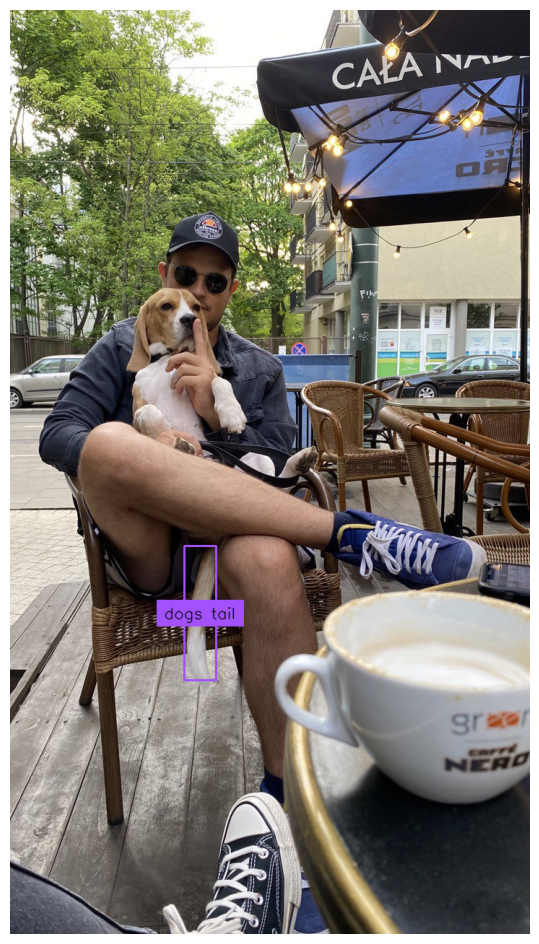

In [17]:
import supervision as sv

resolution_wh = image.size

detections = sv.Detections.from_vlm(
    vlm=sv.VLM.GOOGLE_GEMINI_2_5, result=response.text, resolution_wh=resolution_wh
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    smart_position=True,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_position=sv.Position.CENTER,
)

annotated = image
for annotator in (box_annotator, label_annotator):
    annotated = annotator.annotate(scene=annotated, detections=detections)

sv.plot_image(annotated)

In [18]:
MODEL_NAME = "gemini-2.5-flash"
TEMPERATURE = 0.5

IMAGE_PATH = "dog-2.jpeg"
PROMPT = (
    "Give the segmentation masks peper, salt. "
    + 'Output a JSON list of segmentation masks where each entry contains the 2D bounding box in the key "box_2d", '
    + 'the segmentation mask in key "mask", and the text label in the key "label". Use descriptive labels.'
)

'```json\n[\n  {"box_2d": [660, 248, 777, 365], "mask": "", "label": "peper"},\n  {"box_2d": [693, 387, 836, 532], "mask": "", "label": "salt"}\n]\n```'
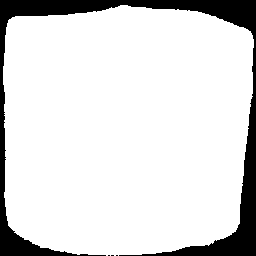
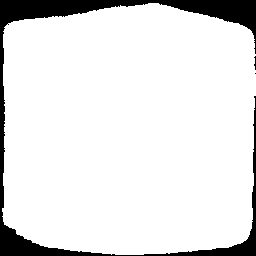

In [19]:
from PIL import Image

image = Image.open(IMAGE_PATH)
width, height = image.size
target_height = int(1024 * height / width)
resized_image = image.resize((1024, target_height), Image.Resampling.LANCZOS)

response = client.models.generate_content(
    model=MODEL_NAME,
    contents=[resized_image, PROMPT],
    config=types.GenerateContentConfig(
        temperature=TEMPERATURE,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(thinking_budget=0),
    ),
)

response.text

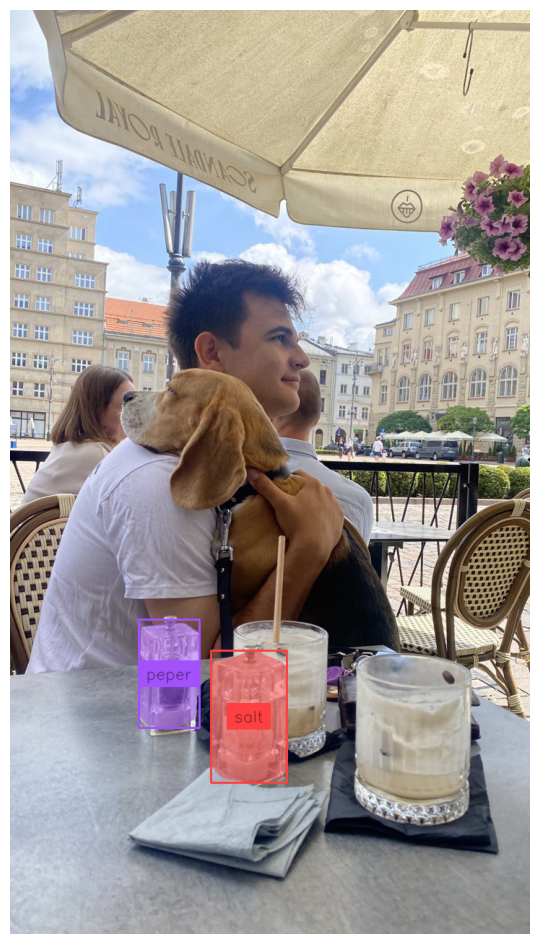

In [20]:
import supervision as sv

resolution_wh = image.size

detections = sv.Detections.from_vlm(
    vlm=sv.VLM.GOOGLE_GEMINI_2_5, result=response.text, resolution_wh=resolution_wh
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    smart_position=True,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_position=sv.Position.CENTER,
)
masks_annotator = sv.MaskAnnotator()

annotated = image
for annotator in (box_annotator, label_annotator, masks_annotator):
    annotated = annotator.annotate(scene=annotated, detections=detections)

sv.plot_image(annotated)

### 한글 프롬프트로 테스트

In [ ]:
MODEL_NAME = "gemini-2.5-flash"
TEMPERATURE = 0.5

IMAGE_PATH = "dog-2.jpeg"
# PROMPT = "pepper와 salt에 대한 분할 마스크를 찾아주세요." \
#         + "출력은 각 항목이 아래 내용을 포함하는 JSON 리스트 형식이어야 합니다. \
#         'box_2d\' 키에는 2D 경계 상자, 'mask\' 키에는 분할 마스크, 'label\' 키에는 텍스트 라벨, \
#         'label'은 내용을 잘 알아볼 수 있도록 서술적으로 작성."

PROMPT = (
    "Give the segmentation masks peper, salt. "
    + 'Output a JSON list of segmentation masks where each entry contains the 2D bounding box in the key "box_2d", '
    + 'the segmentation mask in key "mask", and the text label in the key "label". Use descriptive labels.'
)

In [ ]:
from PIL import Image

image = Image.open(IMAGE_PATH)
width, height = image.size
target_height = int(1024 * height / width)
resized_image = image.resize((1024, target_height), Image.Resampling.LANCZOS)

response = client.models.generate_content(
    model=MODEL_NAME,
    contents=[resized_image, PROMPT],
    config=types.GenerateContentConfig(
        temperature=TEMPERATURE,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(thinking_budget=0),
    ),
)

response.text

In [ ]:
import supervision as sv

resolution_wh = image.size

detections = sv.Detections.from_vlm(
    vlm=sv.VLM.GOOGLE_GEMINI_2_5, result=response.text, resolution_wh=resolution_wh
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    smart_position=True,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_position=sv.Position.CENTER,
)
masks_annotator = sv.MaskAnnotator()

annotated = image
for annotator in (box_annotator, label_annotator, masks_annotator):
    annotated = annotator.annotate(scene=annotated, detections=detections)

sv.plot_image(annotated)

In [21]:
import fitz  # PyMuPDF
import os


def pdf_to_png(pdf_path, output_path, dpi=150):
    """
    PDF 파일의 모든 페이지를 '파일명_[페이지번호].png' 형식의
    PNG 이미지들로 변환하는 함수

    Args:
        pdf_path (str): 변환할 PDF 파일 경로
        output_path (str): 출력할 PNG 파일의 경로 및 이름 형식.
                           예: 'images/result.png'
        dpi (int): 이미지 해상도 (DPI)
    """
    try:
        # 출력 경로에서 디렉토리와 기본 파일명, 확장자를 분리합니다.
        output_dir = os.path.dirname(output_path)
        base_filename = os.path.splitext(os.path.basename(output_path))[0]

        # 출력 디렉토리가 존재하지 않으면 생성합니다.
        if output_dir and not os.path.exists(output_dir):
            os.makedirs(output_dir)

        # PDF 문서를 엽니다.
        pdf_document = fitz.open(pdf_path)

        # PDF의 모든 페이지를 순회합니다.
        for page_num in range(len(pdf_document)):
            # 현재 페이지를 가져옵니다.
            page = pdf_document.load_page(page_num)

            # 해상도를 설정합니다.
            mat = fitz.Matrix(dpi / 72, dpi / 72)

            # 페이지를 이미지로 변환합니다.
            pix = page.get_pixmap(matrix=mat)

            # 새 출력 파일 경로를 생성합니다 (예: 'images/result_1.png').
            new_output_path = os.path.join(
                output_dir, f"{base_filename}_{page_num + 1}.png"
            )

            # PNG 파일로 저장합니다.
            pix.save(new_output_path)
            print(f"페이지 {page_num + 1} 변환 완료: {new_output_path}")

        # 메모리를 정리합니다.
        pdf_document.close()

        print(f"\nPDF가 성공적으로 PNG로 변환되었습니다.")
        return True

    except Exception as e:
        print(f"변환 오류: {e}")
        return False

In [22]:
# --- 사용 예시 ---
# 멀티페이지 PDF 파일 경로
multi_page_pdf = "./data/현대차.pdf"

# 이미지가 저장될 경로와 파일명의 기본 형식을 지정합니다.
# 'output/report.png'로 지정하면 'output' 폴더에 'report_1.png', 'report_2.png'... 로 저장됩니다.
output_file_format = "output/현대차.png"

# 함수를 호출합니다.
pdf_to_png(multi_page_pdf, output_file_format)

페이지 1 변환 완료: output\현대차_1.png
페이지 2 변환 완료: output\현대차_2.png
페이지 3 변환 완료: output\현대차_3.png
페이지 4 변환 완료: output\현대차_4.png
페이지 5 변환 완료: output\현대차_5.png
페이지 6 변환 완료: output\현대차_6.png
페이지 7 변환 완료: output\현대차_7.png
페이지 8 변환 완료: output\현대차_8.png
페이지 9 변환 완료: output\현대차_9.png
페이지 10 변환 완료: output\현대차_10.png
페이지 11 변환 완료: output\현대차_11.png
페이지 12 변환 완료: output\현대차_12.png
페이지 13 변환 완료: output\현대차_13.png
페이지 14 변환 완료: output\현대차_14.png
페이지 15 변환 완료: output\현대차_15.png
페이지 16 변환 완료: output\현대차_16.png

PDF가 성공적으로 PNG로 변환되었습니다.


True

In [28]:
MODEL_NAME = "gemini-2.5-flash"
TEMPERATURE = 0.5

IMAGE_PATH = "./output/현대차_2.png"
PROMPT = (
    "Give the 2d bounding box chart with chart title. "
    + 'Output a JSON list of the 2D bounding box in the key "box_2d", '
    + 'the text label in the key "label". Use descriptive labels.'
)

In [29]:
from PIL import Image

image = Image.open(IMAGE_PATH)
width, height = image.size
target_height = int(1024 * height / width)
resized_image = image.resize((1024, target_height), Image.Resampling.LANCZOS)
resized_image.save("./output/현대차_2_resized.png")

response = client.models.generate_content(
    model=MODEL_NAME,
    contents=[resized_image, PROMPT],
    config=types.GenerateContentConfig(
        temperature=TEMPERATURE,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(thinking_budget=0),
    ),
)



response.text

'```json\n[\n  {"box_2d": [339, 508, 559, 929], "label": "2d bounding box chart with chart title"},\n  {"box_2d": [342, 69, 560, 487], "label": "2d bounding box chart with chart title"},\n  {"box_2d": [676, 513, 868, 929], "label": "2d bounding box chart with chart title"},\n  {"box_2d": [677, 68, 868, 486], "label": "2d bounding box chart with chart title"}\n]\n```'

In [30]:
response.text

'```json\n[\n  {"box_2d": [339, 508, 559, 929], "label": "2d bounding box chart with chart title"},\n  {"box_2d": [342, 69, 560, 487], "label": "2d bounding box chart with chart title"},\n  {"box_2d": [676, 513, 868, 929], "label": "2d bounding box chart with chart title"},\n  {"box_2d": [677, 68, 868, 486], "label": "2d bounding box chart with chart title"}\n]\n```'

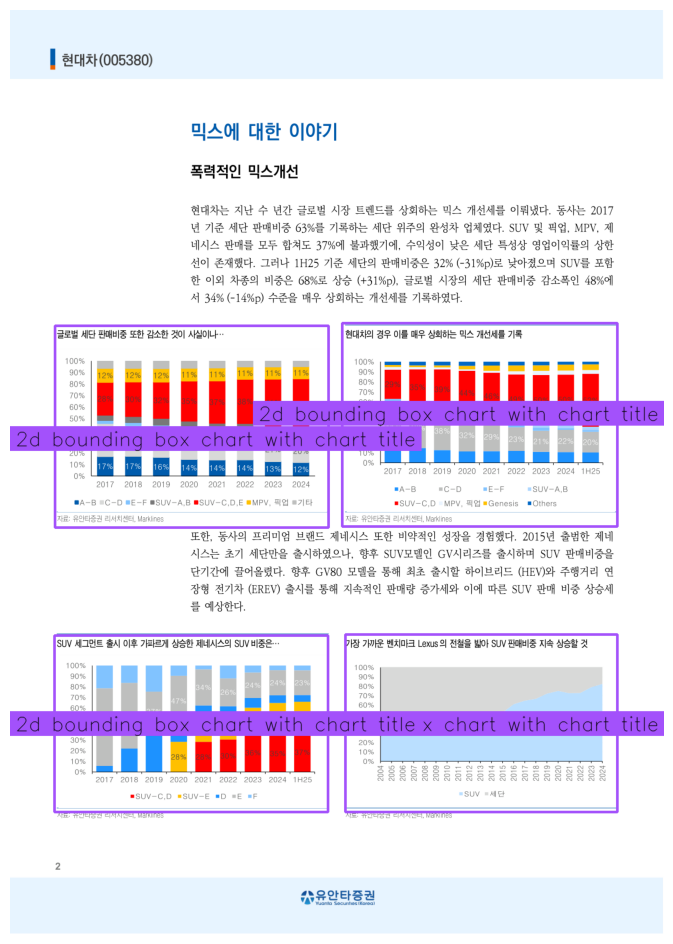

In [31]:
import supervision as sv

resolution_wh = image.size

detections = sv.Detections.from_vlm(
    vlm=sv.VLM.GOOGLE_GEMINI_2_5, result=response.text, resolution_wh=resolution_wh
)

thickness = sv.calculate_optimal_line_thickness(resolution_wh=resolution_wh)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=resolution_wh)

box_annotator = sv.BoxAnnotator(thickness=thickness)
label_annotator = sv.LabelAnnotator(
    smart_position=True,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_position=sv.Position.CENTER,
)
masks_annotator = sv.MaskAnnotator()

annotated = image
for annotator in (box_annotator, label_annotator, masks_annotator):
    annotated = annotator.annotate(scene=annotated, detections=detections)

sv.plot_image(annotated)

In [32]:
print(response.text)

```json
[
  {"box_2d": [339, 508, 559, 929], "label": "2d bounding box chart with chart title"},
  {"box_2d": [342, 69, 560, 487], "label": "2d bounding box chart with chart title"},
  {"box_2d": [676, 513, 868, 929], "label": "2d bounding box chart with chart title"},
  {"box_2d": [677, 68, 868, 486], "label": "2d bounding box chart with chart title"}
]
```
